<a href="https://colab.research.google.com/github/nmfairuz/ML-Coding/blob/main/Linear_Regression_Revision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Linear Regression

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

## Linear Regression with 1 var

x_train -> input var, size in 1000 sqfft

y_train -> traget, price in $1000

In [ ]:
x_train=np.array([1.0, 2.0])
y_train=np.array([300.0, 500.0])
print(f"x_train={x_train}")
print(f"y_train={y_train}")

x_train=[1. 2.]
y_train=[300. 500.]


m -> number of training examples, shape gives row, col -> we need row


In [ ]:
m=x_train.shape[0]
print(f"Number of trianing examples: {m}")

Number of trianing examples: 2


showing the trianing exmaples as ( , )


In [ ]:
for i in range (m):
    print(f"i={i}")
    x_i={x_train[i]}
    y_i={y_train[i]}
    print(f"(x^({i}),y^({i}))=({x_i},{y_i})")

i=0
(x^(0),y^(0))=({np.float64(1.0)},{np.float64(300.0)})
i=1
(x^(1),y^(1))=({np.float64(2.0)},{np.float64(500.0)})


plotting data

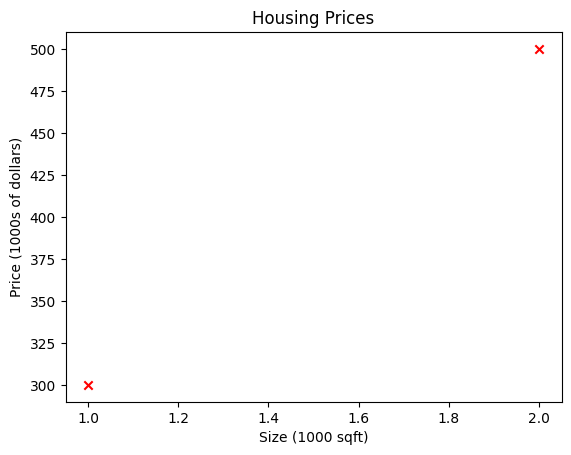

In [ ]:
plt.scatter(x_train,y_train, marker='x', c='r')
plt.title('Housing Prices')
plt.xlabel('Size (1000 sqft)')
plt.ylabel('Price (1000s of dollars)')
plt.show()

prediction is like:

` prediction: y_hat = wx+b `

` f_wb (x)=wx+b `

` f_wb (x^i)=wx^i +b `


where, w & b are parameters. More specificly, w=weight & b=bias

In [ ]:
w=100
b=100
print(f"w = {w}\nb = {b}")

w = 100
b = 100


Computing Func:

In [ ]:
def compute_model_output(x,w,b):
    m=x.shape[0] # get how many rows are there -> we have to run the loop that many times
    f_wb=np.zeros(m) # initialize the vector with 0s, then add vals after computing
    for i in range(m):
        f_wb[i]=w*x[i]+b
    return f_wb

Plotting Predictions:

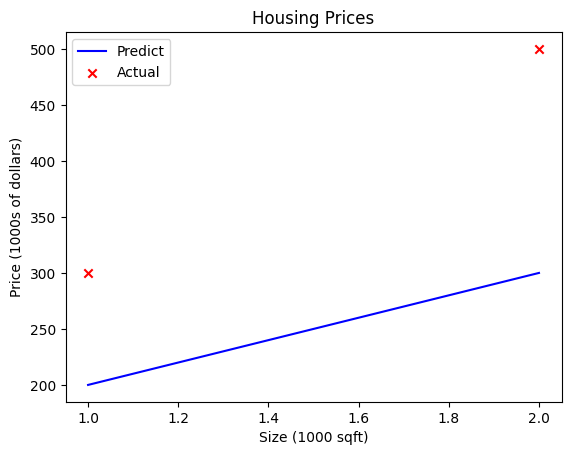

In [ ]:
temp_f_wb=compute_model_output(x_train,w,b)
plt.plot(x_train,temp_f_wb,c='b',label='Predict')
plt.scatter(x_train,y_train,marker='x',c='r',label='Actual')
plt.title('Housing Prices')
plt.xlabel('Size (1000 sqft)')
plt.ylabel('Price (1000s of dollars)')
plt.legend()
plt.show()

function we got is really below the actual outputs, y. So, we need to change weight and bias.

We don't wanna write code for everything again and again, so we will take another func to call it for plotting linear regression.

In [ ]:
def plot_linear_regression_model(w,b, x_train, color):
    temp_f_wb=compute_model_output(x_train,w,b)
    plt.plot(x_train,temp_f_wb,c=color,label='Prediction')
    plt.scatter(x_train,y_train,marker='x',c='r',label='Actual')
    plt.title('Housing Prices')
    plt.xlabel('Size (1000 sqft)')
    plt.ylabel('Price (1000s of dollars)')
    plt.legend()
    plt.show()

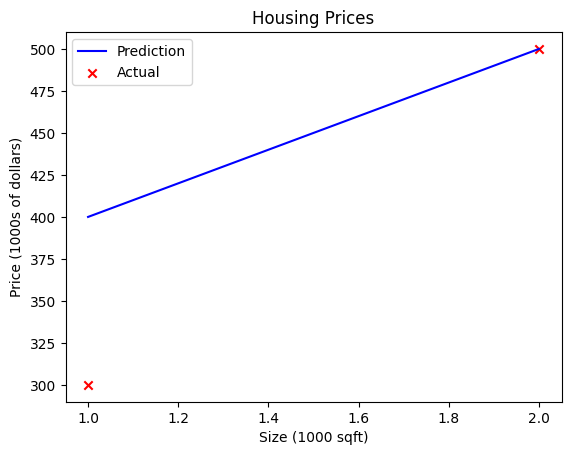

In [ ]:
plot_linear_regression_model(w=100,b=300,x_train=x_train,color='b')

> it's a linear model : w = Slope, b = y intercept




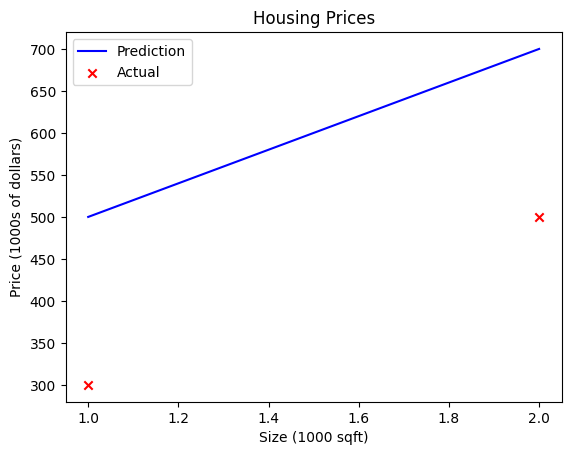

In [ ]:
plot_linear_regression_model(w=200,b=300,x_train=x_train,color='b')

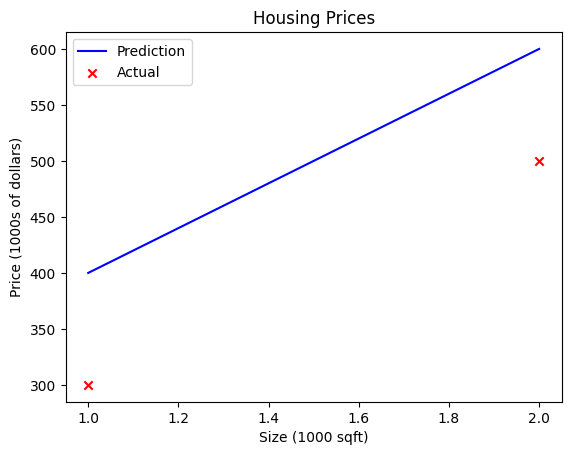

In [ ]:
plot_linear_regression_model(w=200,b=200,x_train=x_train,color='b')

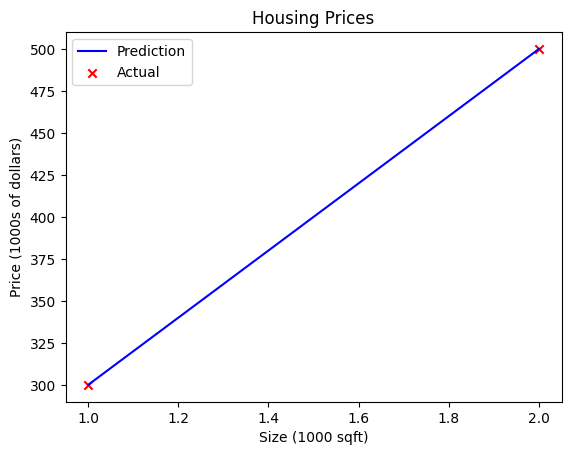

In [ ]:
plot_linear_regression_model(w=200,b=100,x_train=x_train,color='b')

### Cost Func:

For a small number of data points, we can visually estimate a line that fits the data. However, with a large number of inputs (and possibly noisy data), it becomes impossible to manually find the best-fitting line.

Therefore, we define a cost function, which measures how far the model’s predictions are from the actual values. In linear regression, this is typically the mean squared error, i.e., the average of the squared differences between predicted and actual values.

The goal of machine learning is to find parameters (w, b) that minimize this cost, resulting in the best possible fit to the data.

Cost Func for linear regression is:

```
J_wb = 1/2m * (Sum (y_hat_i-y_i)**2)
```

In [ ]:
def compute_cost(x:np.ndarray,y:np.ndarray,w:float|int,b:float|int):
    """
    Computes the cost func for linear regression.
    Args:
        x (ndarray (m,)): Data, inputs/training set
        y (ndarray (m,)): target values
        w,b (scalar)    : model parameters
    Returns total_cost(float): The cost of using w,b as the parameter to find the data points in x and y
    """
    m=x.shape[0] # get how many rows are there
    cost_sum=0 # sum of cost

    for i in range(m):
        f_wb=w*x[i]+b
        cost=(f_wb-y[i])**2
        cost_sum=cost_sum+cost
    total_cost=(1/(2*m))*cost_sum
    return total_cost

In [ ]:
x_train = np.array([1.0, 1.7, 2.0, 2.5, 3.0, 3.2])
y_train = np.array([250, 300, 480,  430,   630, 730,])

w = int(input("Enter a val for w (int): "))
b = int(input("Enter a val for b (int): "))
print(f"Cost for w = {w} and b = {b} is:  {compute_cost(x_train,y_train, w,b)}")

Enter a val for w (int): 500
Enter a val for b (int): 100
Cost for w = 500 and b = 100 is:  304800.0


### Gradient Descent

Enough with manaully guessing each vals for w and b. Time to automate it with gradient descent.

It will work like this:

```
repeat until convergence
{
    w = w  - alpha(partial_diff(Cost_Func)wrt_w)
    b = b  - alpha(**partial_diff**(Cost_Func)wrt_b)
}
```

Here simultaniously means that you calculate the partial derivatives for all the parameters before updating any of the parameters.

The parameters have to be updated simultanously, if you update w first and b later or vice-versa, it won't work.


tips: use a temp var!



In [ ]:
import math, copy
import numpy as np
import matplotlib.pyplot as plt
x_train = np.array([1.0, 1.7, 2.0, 2.5, 3.0, 3.2]) # features
y_train = np.array([250, 300, 480,  430,   630, 730,]) # target vals

Compute Gradient Func:

In [ ]:
def compute_gradient(x,y,w,b):
    """
    Computes gradient for linear regression
    Args:
        x (ndarray (m,)): Data, m examples
        y (ndarray (m,)): target values (given)
        w,b (scalar)    : model parameters

    Returns:
        dj_dw (scalar): The gradient of the cost with respect to the parameters w
        dj_db (scalar): The gradient of the cost with respect to the parameter b
     """
     # number of trianing examples
    m=  x.shape[0]
    dj_dw=0.0
    dj_db=0.0
    for i in range(m):
        y_hat=w*x[i]+b
        dj_dw_i=(y_hat-y[i])*x[i] # error on w for ith training set
        dj_db_i=y_hat-y[i] # error on b for ith training set
        dj_dw+=dj_dw_i
        dj_db+=dj_db_i
    dj_dw=dj_dw/m
    dj_db=dj_db/m
    return dj_dw,dj_db

Gradient Descent Func:

In [ ]:
def gradient_descent(x,y,w_in,b_in, alpha, num_of_iteration, cost_func,gradient_func):
    """
    Performs gradeint descent to fit w,b. Updates w,b by taking num_of_iterms gradeints steps with learning rate alpha
    Args:
        x -> ndarray : Data, trainign examples
        y -> ndarray : target vals
        w_in, b_in : initial val fo w and b
        alpha -> float : learning rate
        num_of_iteration -> int : number of times to run gradient descent
        cost_function -> func to call to produce cost
        gradient_function: func to call to produce gradient


        Return:
            w -> Update val of parameter after running gradient descent
            b -> Update val of parameter after running gradient descent
            J_history -> list of cost values
            p_history (list): History of parameters [w,b]
    """

    # arrays to store cost J and w at each iterations for graphing later

    J_history=[]
    p_history=[]
    b=b_in
    w=w_in
    for i in range(num_of_iteration):
        dj_dw, dj_db=gradient_func(x,y,w,b)
        b=b-alpha*dj_db
        w=w-alpha*dj_dw

        if i < 10000:
            J_history.append(cost_func(x,y,w,b))
            p_history.append([w,b])
        if i % math.ceil(num_of_iteration / 10) == 0:
            print(
                f"Iteration {i}: "
                f"Cost {J_history[-1]:.2e}, "
                f"dj_dw: {dj_dw:.3e}, dj_db: {dj_db:.3e}, "
                f"w: {w:.3e}, b: {b:.3e}"
            )
    return w, b, J_history, p_history

In [ ]:
w_init=0
b_init=0
interations=10000
temp_alpha=1.0e-2
w_final, b_final, J_history, p_history=gradient_descent(x_train,y_train,w_init, b_init, temp_alpha,interations, compute_cost, compute_gradient)
print(f"(w,b) found by gradient descent: ({w_final:8.4f},{b_final:8.4f})")


Iteration 0: Cost 1.09e+05, dj_dw: -1.170e+03, dj_db: -4.700e+02, w: 1.170e+01, b: 4.700e+00
Iteration 1000: Cost 1.78e+03, dj_dw: -1.060e+00, dj_db: 2.599e+00, w: 1.974e+02, b: 3.163e+01
Iteration 2000: Cost 1.74e+03, dj_dw: -4.357e-01, dj_db: 1.068e+00, w: 2.045e+02, b: 1.443e+01
Iteration 3000: Cost 1.74e+03, dj_dw: -1.790e-01, dj_db: 4.388e-01, w: 2.074e+02, b: 7.355e+00
Iteration 4000: Cost 1.74e+03, dj_dw: -7.357e-02, dj_db: 1.803e-01, w: 2.085e+02, b: 4.449e+00
Iteration 5000: Cost 1.74e+03, dj_dw: -3.023e-02, dj_db: 7.410e-02, w: 2.090e+02, b: 3.256e+00
Iteration 6000: Cost 1.74e+03, dj_dw: -1.242e-02, dj_db: 3.045e-02, w: 2.092e+02, b: 2.765e+00
Iteration 7000: Cost 1.74e+03, dj_dw: -5.104e-03, dj_db: 1.251e-02, w: 2.093e+02, b: 2.563e+00
Iteration 8000: Cost 1.74e+03, dj_dw: -2.097e-03, dj_db: 5.141e-03, w: 2.093e+02, b: 2.481e+00
Iteration 9000: Cost 1.74e+03, dj_dw: -8.619e-04, dj_db: 2.113e-03, w: 2.094e+02, b: 2.447e+00
(w,b) found by gradient descent: (209.3590,  2.4325)

### Cost versus iterations of gradient descent

A plot of cost versus iterations is a useful measure of progress in gradient descent. Cost should always decrease in successful runs. The change in cost is so rapid initially, it is useful to plot the initial decent on a different scale than the final descent. In the plots below, note the scale of cost on the axes and the iteration step.

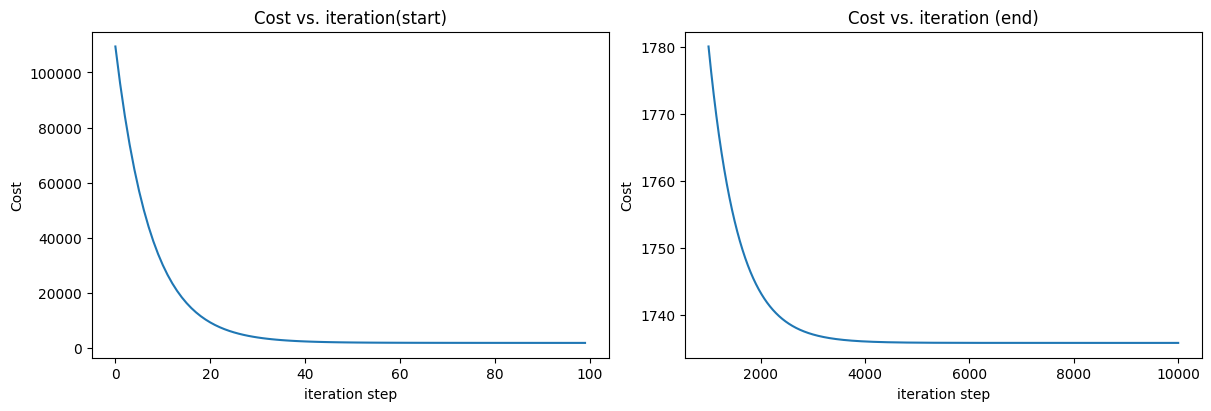

In [ ]:
# plot cost versus iteration
fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout=True, figsize=(12,4))
ax1.plot(J_history[:100])
ax2.plot(1000 + np.arange(len(J_history[1000:])), J_history[1000:])
ax1.set_title("Cost vs. iteration(start)");  ax2.set_title("Cost vs. iteration (end)")
ax1.set_ylabel('Cost');  ax2.set_ylabel('Cost')
ax1.set_xlabel('iteration step')  ;  ax2.set_xlabel('iteration step')
plt.show()


### Predictions

Now that you have discovered the optimal values for the parameters
 and
, you can now use the model to predict housing values based on our learned parameters. As expected, the predicted values are nearly the same as the training values for the same housing. Further, the value not in the prediction is in line with the expected value

In [ ]:
print(f"1000 sqft house prediction {w_final*1.0 + b_final:0.1f} Thousand dollars")
print(f"1200 sqft house prediction {w_final*1.2 + b_final:0.1f} Thousand dollars")
print(f"2000 sqft house prediction {w_final*2.0 + b_final:0.1f} Thousand dollars")

1000 sqft house prediction 211.8 Thousand dollars
1200 sqft house prediction 253.7 Thousand dollars
2000 sqft house prediction 421.2 Thousand dollars


## Multiple Variable Linear Regression (Regression with Multiple features/inputs)

We use the example of housing price prediction. The training dataset contains three examples with four features (size, bedrooms, floors and, age)

In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(precision=2)  # reduced display precision on numpy arrays


x_train=np.array([[2104,5,1,45], [1416,3,2,40],[852,2,1,35]])
y_train=np.array([460,232,178])

x_train isn't a normal array this time, it's an array of arrays -> Matrix

or u can say a vector of vectors = Matrix

X matrix ->

    rows : training examples
    cols : each example's features

In [ ]:
print(f"X shape: {x_train.shape}, x type: {type(x_train)}")
print(x_train)
print(f"y shape: {y_train.shape}, y type: {type(y_train)}")
print(y_train)

X shape: (3, 4), x type: <class 'numpy.ndarray'>
[[2104    5    1   45]
 [1416    3    2   40]
 [ 852    2    1   35]]
y shape: (3,), y type: <class 'numpy.ndarray'>
[460 232 178]


Since we have multiple features of one training example, we need to have multiple parameters for those features as well.

Each features gets one parameters. [n features -> n parameters]

Therefore, now, parameter w is also a vector with n parameters.

prediction now works like this:

```
y_hat = f_wb(x) = w_0*x_0 + w_1*x_1 + w_2*x_2 + b
```

This is simply vector dot product:

`y_hat = f_wb(x) = w.x + b`

### Single Prediction element by element

In [ ]:
def predict_single_loop(x,w,b):
    """
    Single predict using linear regression
    Args:
        x -> ndarray : shape (n,) with multiple features
        w -> ndarray : shape (n,) model parameters
        b -> scaler : model parameter
    Returns:
        p -> scalar : model prediction
    """

    n=x.shape[0]
    p=0
    for i in range(n):
        p_i=x[i]*w[i]
        p=p+p_i
    p=p+b
    return p

In [ ]:
b_init=785.62
w_init=np.array([0.391335,18.75376,-53.63,-26.42])
print(f"w_init shape: {w_init.shape}, w_init type: {type(w_init)}")
print(f"b_init type: {type(b_init)}")

print()
# get a row from training data
x_vec=x_train[0:]
print(f"x_vec shape {x_vec.shape}, \n\nx_vec value: \n{x_vec}")

# make a prediction
y_hat=predict_single_loop(x_vec, w=w_init, b=b_init)
print(f"f_wb {y_hat.shape}, \n\nprediction: {y_hat}")

w_init shape: (4,), w_init type: <class 'numpy.ndarray'>
b_init type: <class 'float'>

x_vec shape (3, 4), 

x_vec value: 
[[2104    5    1   45]
 [1416    3    2   40]
 [ 852    2    1   35]]
f_wb (4,), 

prediction: [-17528.45    736.58    769.89   -323.67]


> Note the shape of x_vec. It is a 1-D NumPy vector with 4 elements, (4,). The result, f_wb is a scalar.

### Compute Cost With Multiple Variables

In [ ]:
def compute_cost(x,y,w,b):
    """
    Compute cost:
        Args:
            x -> ndarray (m,n) : Datam M examples with n features
            y -> ndarray (m,) : target vals
            w -> ndarray (n,) : model parameters
            b -> scalar : model parameter
        Returns:
            cost -> scalar : cost
    """
    m=x.shape[0]
    cost=0.0
    for i in range(m):
        y_hat_i=np.dot(x[i], w)+b
        cost=cost+(y_hat_i-y[i])**2

    cost=cost/(2*m)
    return cost

In [ ]:
cost=compute_cost(x_train, y_train, w_init, b_init)
print(f"Cost at optimal w: {cost}")

Cost at optimal w: 0.016726310466653054


### Compute Gradient with Multiple Variables

In [ ]:
def compute_gradient(x,y,w,b):
    """
    Compiutes the gradeint for linear regression
    Args:
        x -> ndarray (m,n) : Data, m exmaples with n features
        y -> ndarray (m,) : target vals
        w -> ndarray (n,) : model parameters
        b -> scalar : model parameter
    Returns:
        dj_dw -> ndarray(n,) : The gradeints of the cost with rest to the parameters w
        dj_db -> scalar : The gradeint of the cost with respect to b
    """
    m, n = x.shape
    dj_dw=np.zeros((n,))
    dj_db=0

    # loop for counting over all the training examples
    for i in range(m):
        error=(np.dot(x[i], w)+b)-y[i]
        # loop for counting on one training example
        for j in range(n):
            dj_dw[j]=dj_dw[j]+error*x[i,j]
        dj_db=dj_db+error

    dj_dw=dj_dw/m
    dj_db=dj_db/m
    return dj_db, dj_db

compute and display gradient

In [ ]:
temp_dj_db, temp_dj_dw=compute_gradient(x_train, y_train, w_init, b_init)
print(f"dj_db at initial w,b: {temp_dj_db}")
print(f"dj_dw at initial w,b: {temp_dj_dw}")

dj_db at initial w,b: 0.13140666666655912
dj_dw at initial w,b: 0.13140666666655912


### Gradient Descent With Multiple Variables

In [ ]:
def gradient_descent(x,y,w_init, b_init, cost_function, gradient_function, alpha, num_of_iteration):
    """
    Performs batch gradeitn descent to learn w and b. updates w and b by taking number_of_iteration gradient steps with learning rate alpha
    Args:
        x -> ndarray(m,n): Data, m exmaples with n features
        y -> ndarray(m,): target vals
        w_init -> ndarrary(n,): initial model parameter
        b_init -> scaler: initial model parameter
        cost_function: function to call to compute the cost
        gradient_function: function to call to compute the gradient
        alpha -> float : learning rate
        num_of_iteration -> int : number of iterations to run gradeint descent

    Returns:
        w -> narray(n,) : updated vals of parameters
        b -> scaler : updated val of parameter

    """

    # an array to store cost J and W at each iteration
    # u can use it for graphing

    J_history=[]
    w=copy.deepcopy(w_init)
    b=b_init

    for i in range(num_of_iteration):
        # calc gradeitn descent and update paramenters
        dj_db,dj_dw=gradient_function(x, y, w, b)

        # udpate pamars using w, b, alpha, gradient
        w=w-alpha*dj_dw
        b=b-alpha*dj_db

        # save cost J at each iterations
        if i < 10000:
            J_history.append(cost_function(x,y, w,b))

        # print cost every interval 10 times or as many itenrations
        if i% math.ceil(num_of_iteration / 10) == 0:
            print(f"Iteration {i:4d}: Cost {J_history[-1]:8.2f}   ")
    return w,b,J_history # return final w,b,J history for graphing

In [ ]:
import copy
initial_w=np.zeros_like(w_init)
initial_b=0

iterations=1000
alpha=5.0e-7

w_final, b_final, J_history = gradient_descent(x_train, y_train, w_init, b_init, compute_cost, compute_gradient, alpha, iterations)

print(f"b,w found by gradient descent: {b_final:0.2f}, {w_final}")

m,_=x_train.shape
for i in range(m):
    print(f"Prediction : {np.dot(x_train[i], w_final)+ b_final:0.2f}, target val: {y_train[i]}")

Iteration    0: Cost     0.02   
Iteration  100: Cost     0.02   
Iteration  200: Cost     0.01   
Iteration  300: Cost     0.01   
Iteration  400: Cost     0.01   
Iteration  500: Cost     0.01   
Iteration  600: Cost     0.01   
Iteration  700: Cost     0.01   
Iteration  800: Cost     0.01   
Iteration  900: Cost     0.01   
b,w found by gradient descent: 785.62, [  0.39  18.75 -53.63 -26.42]
Prediction : 460.13, target val: 460
Prediction : 231.88, target val: 232
Prediction : 178.17, target val: 178


## Trying out different learning rates:

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


np.random.seed(42)

# House sizes in square feet
X = np.random.randint(800, 4000, 100)

# Price = 200 * size + noise
noise = np.random.randint(-50000, 50000, 100)

y = 200 * X + noise

m = len(X)

def compute_cost(w, b):
    y_pred = w * X + b
    return (1 / (2 * m)) * np.sum((y_pred - y) ** 2)

def gradient_descent(alpha, iterations):
    w = 0
    b = 0

    cost_history = []

    for _ in range(iterations):
        y_pred = w * X + b

        dw = (1 / m) * np.sum((y_pred - y) * X)
        db = (1 / m) * np.sum(y_pred - y)

        w = w - alpha * dw
        b = b - alpha * db

        cost_history.append(compute_cost(w, b))

    return cost_history

/tmp/ipykernel_1147/2034588771.py:19: RuntimeWarning: overflow encountered in square
  return (1 / (2 * m)) * np.sum((y_pred - y) ** 2)
/tmp/ipykernel_1147/2034588771.py:30: RuntimeWarning: overflow encountered in multiply
  dw = (1 / m) * np.sum((y_pred - y) * X)
/tmp/ipykernel_1147/2034588771.py:33: RuntimeWarning: invalid value encountered in scalar subtract
  w = w - alpha * dw
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/tmp/ipykernel_1147/2034588771.py:34: RuntimeWarning: invalid value encountered in scalar subtract
  b = b - alpha * db
/tmp/ipykernel_1147/2034588771.py:18: RuntimeWarning: overflow encountered in multiply
  y_pred = w * X + b
/tmp/ipykernel_1147/2034588771.py:28: RuntimeWarning: overflow encountered in multiply
  y_pred = w * X + b


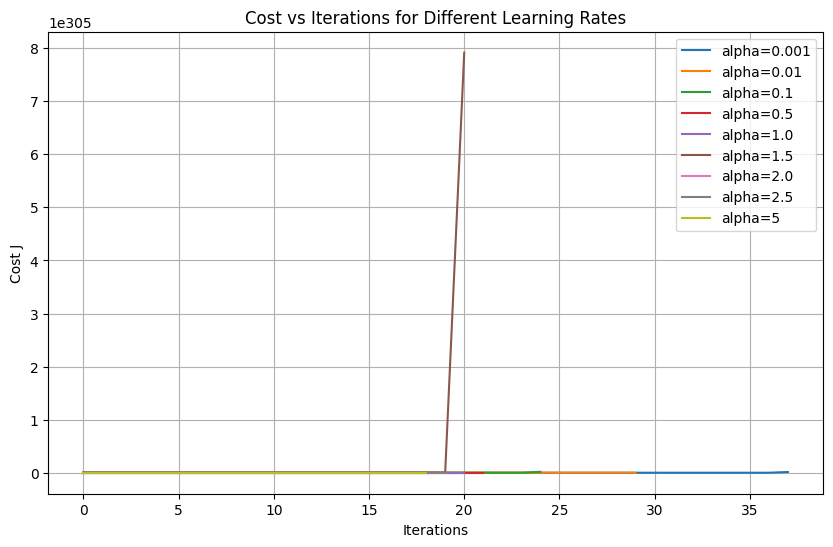

In [ ]:
learning_rates = [0.001, 0.01, 0.1, 0.5, 1.0, 1.5, 2.0, 2.5, 5]

plt.figure(figsize=(10, 6))

for alpha in learning_rates:
    history = gradient_descent(alpha, 300)
    plt.plot(history, label=f"alpha={alpha}")

plt.xlabel("Iterations")
plt.ylabel("Cost J")
plt.title("Cost vs Iterations for Different Learning Rates")
plt.legend()
plt.grid(True)
plt.show()

## Using SciKit Learn

In [ ]:
import numpy as np
np.random.seed(42)
x_train = np.random.randint(800, 4000, 100)
noise = np.random.normal(0, 40000, 100)
y_train = 50000 + 180 * x_train + noise
x_train = x_train.reshape(-1, 1)

In [ ]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [ ]:
print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)

Slope: 181.3844143833907
Intercept: 48228.11342305003


In [ ]:
predictions = model.predict(x_train)

print(predictions[:5])

[769049.77618264 349326.24129948 428047.07714187 398300.03318299
 391951.57867958]


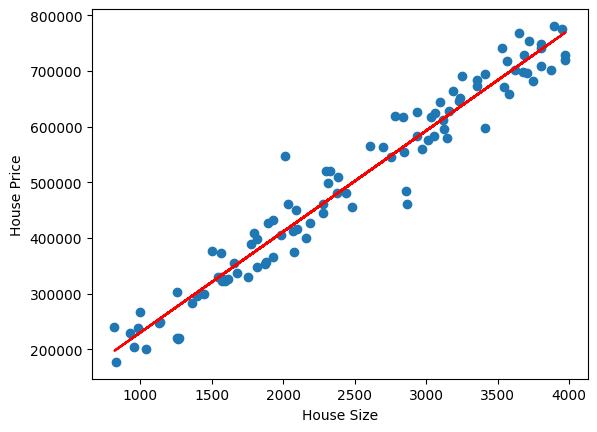

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(x_train, y_train)

plt.plot(x_train, predictions, 'r')

plt.xlabel("House Size")
plt.ylabel("House Price")

plt.show()

In [ ]:
print(model.predict([[1000]]))

[229612.52780644]


## Excercise using SciKit Learn

In [ ]:
from sklearn.datasets import fetch_california_housing
housing=fetch_california_housing()

x=housing.data
y=housing.target
print(x.shape, y.shape)

(20640, 8) (20640,)


It has 20640 rows and 8 cols, means training examples: 20640, features: 8

Split with train_set and validation/testing set

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test, y_train, y_test=train_test_split(x, y, test_size=0.2, random_state=42)

Creating the model

In [ ]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()

Training the model:

In [ ]:
model.fit(X_train, y_train)

LinearRegression()

Predict Using that model:

In [ ]:
y_predict=model.predict(X_test)

### R2_Score:
> "How much of the variation in house prices can my model explain?"

| R²  | Meaning                             |
| --- | ----------------------------------- |
| 1.0 | Perfect predictions                 |
| 0.9 | Excellent                           |
| 0.7 | Pretty good                         |
| 0.5 | Decent                              |
| 0.0 | No better than guessing the average |
| < 0 | Worse than guessing the average     |


In [ ]:
from sklearn.metrics import r2_score
print(r2_score(y_test, y_predict))

0.5757877060324524


#### MAE:

> MAE is another way to measure how completely wrong your machine learning model's predictions are.

Unlike MSE (Mean Squared Error), which squares the errors, MAE keeps things completely linear.

In [ ]:
from sklearn.metrics import mean_absolute_error
print(f"MAE: {mean_absolute_error(y_test, y_predict)}")

MAE: 0.533200130495698


#### MSE:

> MSE is the most popular metric for regression. Instead of taking the absolute value of the errors like MAE does, MSE squares them.

In [ ]:
from sklearn.metrics import mean_squared_error
print(f"MSE: {mean_squared_error(y_test, y_predict)}")

MSE: 0.5558915986952422


| Metric | Your Result | Meaning                                  |
| ------ | ----------- | ---------------------------------------- |
| R²     | 0.576       | Model explains ~57.6% of price variation |
| MAE    | 0.533       | Average absolute error                   |
| MSE    | 0.556       | Average squared error                    |


In [ ]:
print(housing.feature_names)


['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [ ]:
print(model.coef_)

[ 4.48674910e-01  9.72425752e-03 -1.23323343e-01  7.83144907e-01
 -2.02962058e-06 -3.52631849e-03 -4.19792487e-01 -4.33708065e-01]


Predicting data using the model:

In [ ]:
my_house = [[
    5.0,      # Median Income
    20,       # House Age
    6.0,      # Avg Rooms
    1.2,      # Avg Bedrooms
    1000,     # Population
    3.0,      # Avg Occupancy
    37.5,     # Latitude
    -122.0    # Longitude
]]

prediction = model.predict(my_house)

print(prediction)

[2.77197293]


# Feature Engineering



Feature engineering is mainly useful for DeeP Neural Networks and stuffs like that, for Linear Regression, it won't cause noticible difference or improvement.

It's jsut for practice!

## No Scaling

In [ ]:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing()

X = housing.data
y = housing.target

print(X[:5])

[[ 8.32520000e+00  4.10000000e+01  6.98412698e+00  1.02380952e+00
   3.22000000e+02  2.55555556e+00  3.78800000e+01 -1.22230000e+02]
 [ 8.30140000e+00  2.10000000e+01  6.23813708e+00  9.71880492e-01
   2.40100000e+03  2.10984183e+00  3.78600000e+01 -1.22220000e+02]
 [ 7.25740000e+00  5.20000000e+01  8.28813559e+00  1.07344633e+00
   4.96000000e+02  2.80225989e+00  3.78500000e+01 -1.22240000e+02]
 [ 5.64310000e+00  5.20000000e+01  5.81735160e+00  1.07305936e+00
   5.58000000e+02  2.54794521e+00  3.78500000e+01 -1.22250000e+02]
 [ 3.84620000e+00  5.20000000e+01  6.28185328e+00  1.08108108e+00
   5.65000000e+02  2.18146718e+00  3.78500000e+01 -1.22250000e+02]]


Observe the feature ranges:

In [ ]:
print(f"Range: {X.max(axis=0)- X.min(axis=0)}")

Range: [1.45002000e+01 5.10000000e+01 1.41062937e+02 3.37333333e+01
 3.56790000e+04 1.24264103e+03 9.41000000e+00 1.00400000e+01]


Some range difference is 9.41 and some are 3567. This causes different impact for different weights.

```
Larger Difference -> Lower Impact for weight difference

Less Difference -> Higher Impact for weight difference
```

## Divide by Max:

In [ ]:
X_max_scaled=X/X.max(axis=0)
print(X_max_scaled[:5])

[[0.55500963 0.78846154 0.0492155  0.03005312 0.00902416 0.00205541
  0.90297974 1.06928528]
 [0.55342298 0.40384615 0.04395869 0.02852878 0.06728883 0.00169692
  0.90250298 1.0691978 ]
 [0.48382344 1.         0.05840454 0.03151017 0.01390057 0.00225383
  0.9022646  1.06937276]
 [0.37620416 1.         0.04099351 0.03149881 0.01563814 0.00204929
  0.9022646  1.06946024]
 [0.25641162 1.         0.04426674 0.03173428 0.01583431 0.00175453
  0.9022646  1.06946024]]


After dividing every col with their max val of their col, now range is from 0-1

In [ ]:
print(f"Range: {X_max_scaled.max(axis=0)- X_max_scaled.min(axis=0)}")

Range: [0.96667356 0.98076923 0.99403735 0.99021526 0.99991592 0.99944318
 0.22431466 0.08783134]


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_max_scaled, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Max Scaling R²:", r2_score(y_test, y_pred))

Max Scaling R²: 0.5757877060324534


Didn't change much from the without scaling version to Max Scaling Version!

## Mean Normalization:

Each col vals get divided by their mean val!

In [ ]:
X_mean_scaled = (X - np.mean(X, axis=0)) / (np.max(X, axis=0) - np.min(X, axis=0))
print(X_mean_scaled[:5])

[[ 3.07204659e-01  2.42363011e-01  1.10243504e-02 -2.16004820e-03
  -3.09279056e-02 -4.14520037e-04  2.38909518e-01 -2.64969676e-01]
 [ 3.05563302e-01 -1.49793852e-01  5.73600236e-03 -3.69944637e-03
   2.73416647e-02 -7.73202648e-04  2.36784120e-01 -2.63973660e-01]
 [ 2.33564295e-01  4.58049286e-01  2.02685121e-02 -6.88601440e-04
  -2.60510873e-02 -2.15987777e-04  2.35721420e-01 -2.65965691e-01]
 [ 1.22234797e-01  4.58049286e-01  2.75303963e-03 -7.00072793e-04
  -2.43133704e-02 -4.20644372e-04  2.35721420e-01 -2.66961707e-01]
 [-1.68763210e-03  4.58049286e-01  6.04590800e-03 -4.62274759e-04
  -2.41171766e-02 -7.15563030e-04  2.35721420e-01 -2.66961707e-01]]


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_mean_scaled, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Mean Scaling R²:", r2_score(y_test, y_pred))

Mean Scaling R²: 0.5757877060324511


This didn't change from the first two either!

In [ ]:
X_z_scaled = (
    X - np.mean(X, axis=0)
) / np.std(X, axis=0)

# repeat training
X_train, X_test, y_train, y_test = train_test_split(
    X_z_scaled, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Max Scaling R²:", r2_score(y_test, y_pred))

Max Scaling R²: 0.5757877060324511


This R2 score hasn't changed either!

## StandardScaler

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
X_Scaled=scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_Scaled, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Max Scaling R²:", r2_score(y_test, y_pred))

Max Scaling R²: 0.5757877060324511


> SKLEARN's LinearRegression model finds the coefficients using a linear algebra solution (least squares), not by repeatedly taking gradient descent steps.

This is why there was no difference after scaling diffrent ways!

##  Polynomial Regression

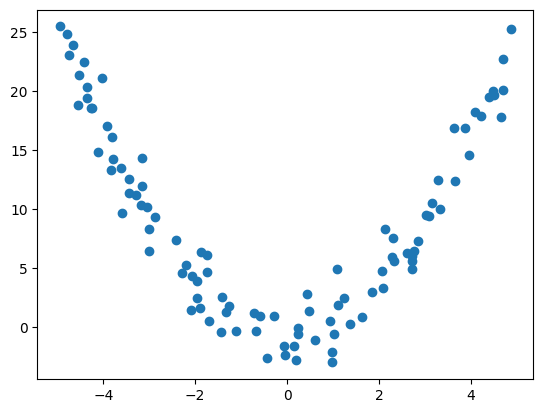

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
X = np.random.uniform(-5, 5, 100)
y = X**2 + np.random.normal(0, 2, 100)
X = X.reshape(-1, 1)
plt.scatter(X, y)
plt.show()

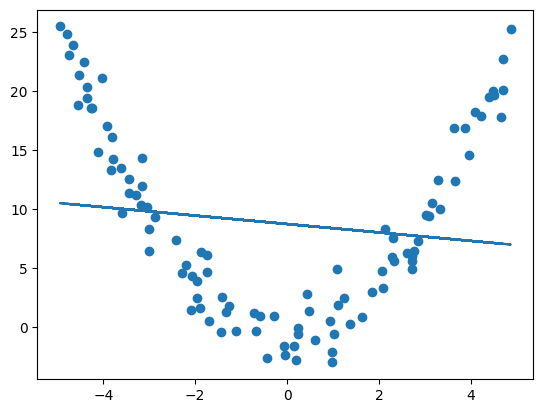

In [ ]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)
plt.scatter(X, y)
plt.plot(X, y_pred)
plt.show()

Linear func woon't fit the curved dataset!

Therfore, we will use polynomial func!

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
poly=PolynomialFeatures(degree=2)
X_poly=poly.fit_transform(X)
print(X[:5])
print()
print(X_poly[:5])

[[-1.25459881]
 [ 4.50714306]
 [ 2.31993942]
 [ 0.98658484]
 [-3.4398136 ]]

[[ 1.         -1.25459881  1.57401818]
 [ 1.          4.50714306 20.3143386 ]
 [ 1.          2.31993942  5.3821189 ]
 [ 1.          0.98658484  0.97334965]
 [ 1.         -3.4398136  11.83231757]]


The values of X_poly are : [1, x, x²]

x=3 becomes -> [1, 3, 9]

In [ ]:
model=LinearRegression()
model.fit(X_poly, y)
y_pred=model.predict(X_poly)

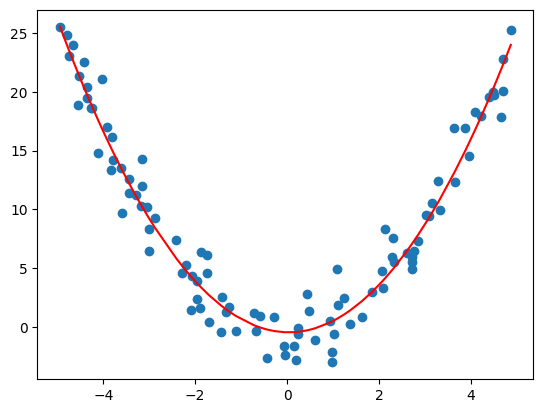

In [ ]:
sort_idx=np.argsort(X.flatten())
plt.scatter(X,y)
plt.plot(X[sort_idx], y_pred[sort_idx], "red")
plt.show()

In [ ]:
print(X.shape)

(100, 1)


In [ ]:
print(X_poly.shape)

(100, 3)


### Polynomial Regression (Scikit-Learn)

**Idea:**
Polynomial Regression is still Linear Regression, but we create extra features such as (x^2, x^3), and interaction terms before training.

---

#### Creating Polynomial Features

```python
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)

X_poly = poly.fit_transform(X)
```

---

#### What does `degree=2` do?

For a single feature:

```text
x
```

becomes

```text
1, x, x²
```

Example:

```text
x = 3

→ [1, 3, 9]
```

---

#### Multiple Features

For:

```text
x1, x2
```

Degree 2 creates:

```text
1
x1
x2
x1²
x1x2
x2²
```

It includes:

* Powers (x₁², x₂²)
* Interaction terms (x₁x₂)

---

#### California Housing Dataset

Original:

```python
X.shape
# (20640, 8)
```

After:

```python
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)
```

Result:

```python
X_poly.shape
# (20640, 45)
```

because sklearn generates:

```text
1
All original features
All squared features
All pairwise interactions
```

Examples:

```text
MedInc²
HouseAge²
MedInc × HouseAge
MedInc × Longitude
AveRooms × Population
...
```

---

#### Training

```python
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_poly, y)
```

Even though it's called "Polynomial Regression", the model is still:

```python
LinearRegression()
```

The polynomial behavior comes from the engineered features, not from a different model.

---

#### Key Idea

PolynomialFeatures generates **all feature combinations whose total degree is ≤ the specified degree**.

For degree 2:

```text
x⁰, x¹, x²
and all pairwise interactions
```

This is a form of **Feature Engineering** because we create new features from existing ones.


In [ ]:
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import PolynomialFeatures

housing = fetch_california_housing()
X = housing.data
y = housing.target
print("Original:", X.shape)

Original: (20640, 8)


In [ ]:
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)
print("Polynomial:", X_poly.shape)

Polynomial: (20640, 45)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Original R²:", r2_score(y_test, y_pred))

Original R²: 0.5757877060324524


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_poly, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Polynomial R²:", r2_score(y_test, y_pred))

Polynomial R²: 0.6456819711504156


R2 Score improved!!!

Using polynomials, we have actually given the model new information (new features).

So, R2 Changed!
